In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('Dataset/archive(2)/train.csv').sample(5000, random_state=42)
print(df.shape)
df.head()

(5000, 13)


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
40907,5599,HR,region_16,Bachelor's,m,other,1,35,5.0,10,0,47,0
51939,73176,Sales & Marketing,region_7,Bachelor's,m,other,3,33,1.0,4,0,51,0
6978,13157,Finance,region_2,Bachelor's,m,other,2,38,3.0,11,0,64,0
12814,7458,Operations,region_22,Bachelor's,f,other,1,33,1.0,8,0,56,0
22921,28446,Technology,region_7,Bachelor's,f,other,1,37,1.0,4,0,80,0


In [3]:
print(df.isnull().sum()[df.isnull().sum() > 0])

education               212
previous_year_rating    386
dtype: int64


In [4]:
df = df.drop(columns=['employee_id', 'is_promoted'])
num = df.select_dtypes(include=['int64', 'float64']).columns
cat = df.select_dtypes(include='object').columns

pre = ColumnTransformer([
    ('n', Pipeline([('fill', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num),
    ('c', Pipeline([('fill', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat)
])

x = pre.fit_transform(df)
x.shape

(5000, 57)

## PCA


Explained variance: [0.18968479 0.13356783]


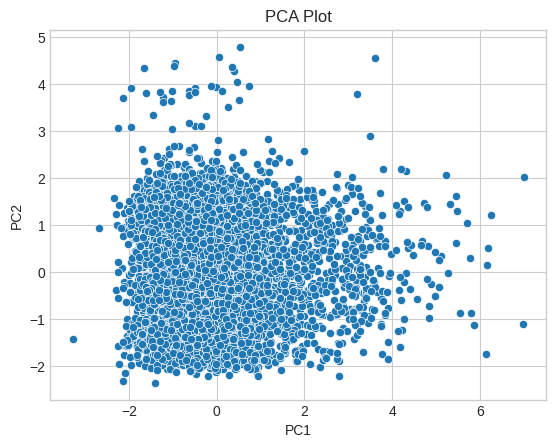

In [5]:
pca = PCA(n_components=2, random_state=42)
p2 = pca.fit_transform(x)
p = pd.DataFrame(p2, columns=['PC1', 'PC2'])

print('Explained variance:', pca.explained_variance_ratio_)
sns.scatterplot(data=p, x='PC1', y='PC2', s=35)
plt.title('PCA Plot')
plt.show()

## KMeans


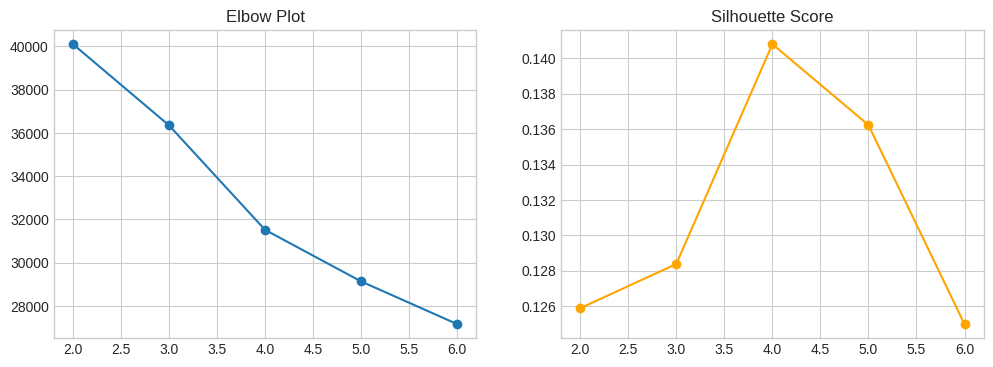

Best k = 4


In [6]:
ks = range(2, 7)
sil = []
inn = []

for k in ks:
    m = KMeans(n_clusters=k, random_state=42, n_init=10)
    y = m.fit_predict(x)
    sil.append(silhouette_score(x, y))
    inn.append(m.inertia_)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inn, marker='o')
ax[0].set_title('Elbow Plot')
ax[1].plot(list(ks), sil, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
plt.show()

k = list(ks)[np.argmax(sil)]
print('Best k =', k)

KMeans silhouette on PCA: 0.301


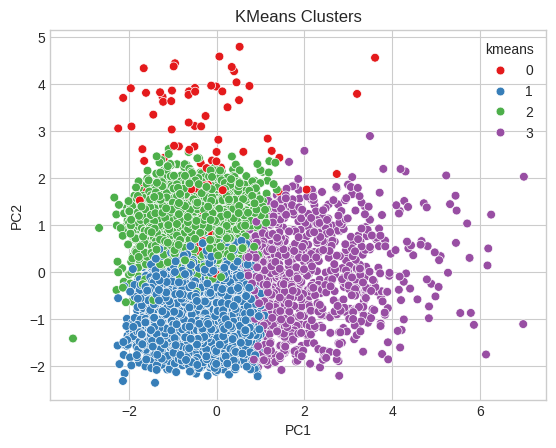

kmeans
0     100
1    2367
2    1549
3     984
Name: count, dtype: int64


In [7]:
km = KMeans(n_clusters=k, random_state=42, n_init=10)
p['kmeans'] = km.fit_predict(x)
print('KMeans silhouette on PCA:', round(silhouette_score(p2, p['kmeans']), 3))

sns.scatterplot(data=p, x='PC1', y='PC2', hue='kmeans', palette='Set1', s=40)
plt.title('KMeans Clusters')
plt.show()

print(p['kmeans'].value_counts().sort_index())

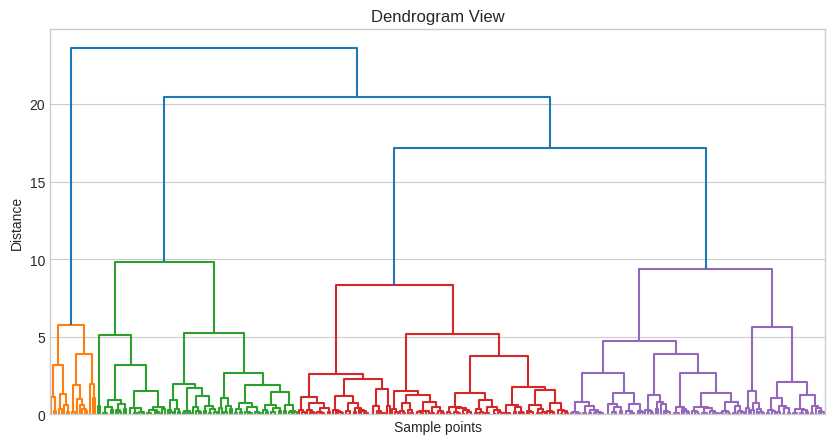

In [8]:
tree = linkage(p2[:300], method='ward')

plt.figure(figsize=(10, 5))
dendrogram(tree, no_labels=True, color_threshold=None)
plt.title('Dendrogram View')
plt.xlabel('Sample points')
plt.ylabel('Distance')
plt.show()

## DBSCAN


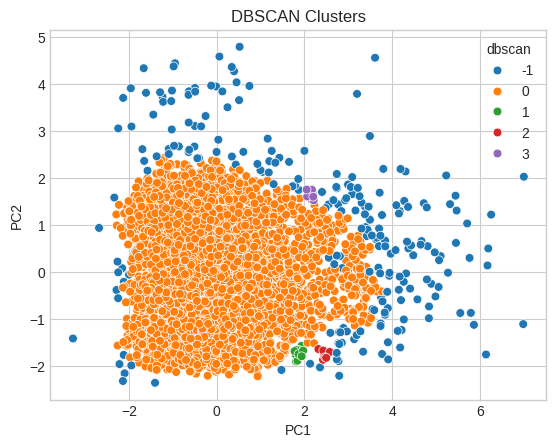

dbscan
-1     226
 0    4748
 1      11
 2       8
 3       7
Name: count, dtype: int64


In [9]:
db = DBSCAN(eps=0.2, min_samples=8)
p['dbscan'] = db.fit_predict(p2)

sns.scatterplot(data=p, x='PC1', y='PC2', hue='dbscan', palette='tab10', s=40)
plt.title('DBSCAN Clusters')
plt.show()

print(p['dbscan'].value_counts().sort_index())

## Agglomerative Clustering


Agglomerative silhouette on PCA: 0.038


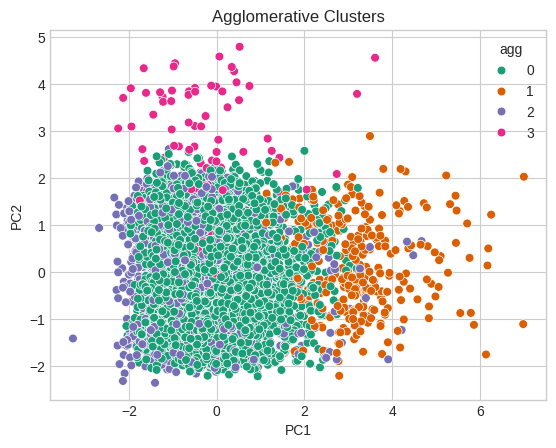

agg
0    3714
1     302
2     884
3     100
Name: count, dtype: int64


In [10]:
ag = AgglomerativeClustering(n_clusters=k)
p['agg'] = ag.fit_predict(x)
print('Agglomerative silhouette on PCA:', round(silhouette_score(p2, p['agg']), 3))

sns.scatterplot(data=p, x='PC1', y='PC2', hue='agg', palette='Dark2', s=40)
plt.title('Agglomerative Clusters')
plt.show()

print(p['agg'].value_counts().sort_index())

In [11]:
pd.DataFrame({
    'model': ['KMeans', 'DBSCAN', 'Agglomerative'],
    'groups': [p['kmeans'].nunique(), p['dbscan'].nunique(), p['agg'].nunique()]
})

,model,groups
0,KMeans,4
1,DBSCAN,5
2,Agglomerative,4
